🌙 Raat ko total activities: 100

👤 Users:
user_id
ahmed     23
ali       22
usman     20
fatima    18
sara      17
Name: count, dtype: int64


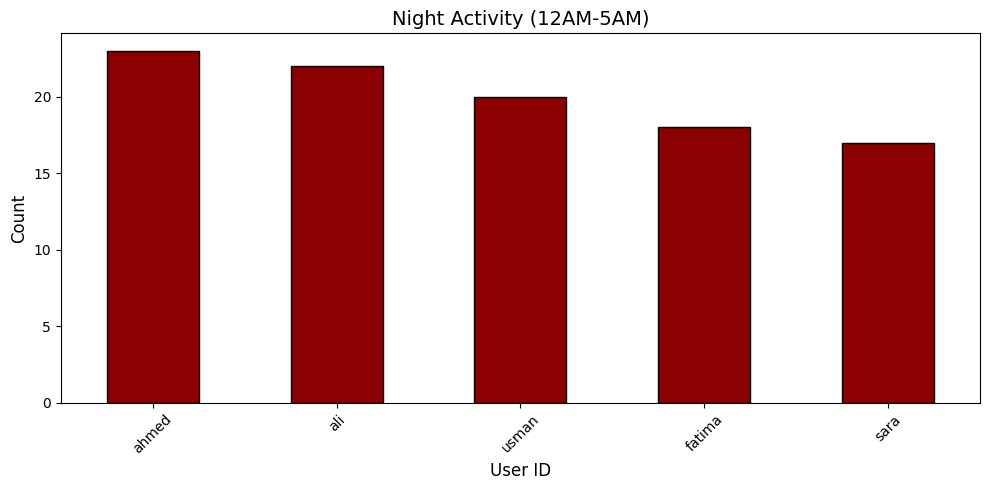

✈️ Foreign locations: 100

🌍 Countries:
location
North Korea    22
Iran           14
UAE            14
China          13
India          13
USA            12
Russia          8
UK              4
Name: count, dtype: int64


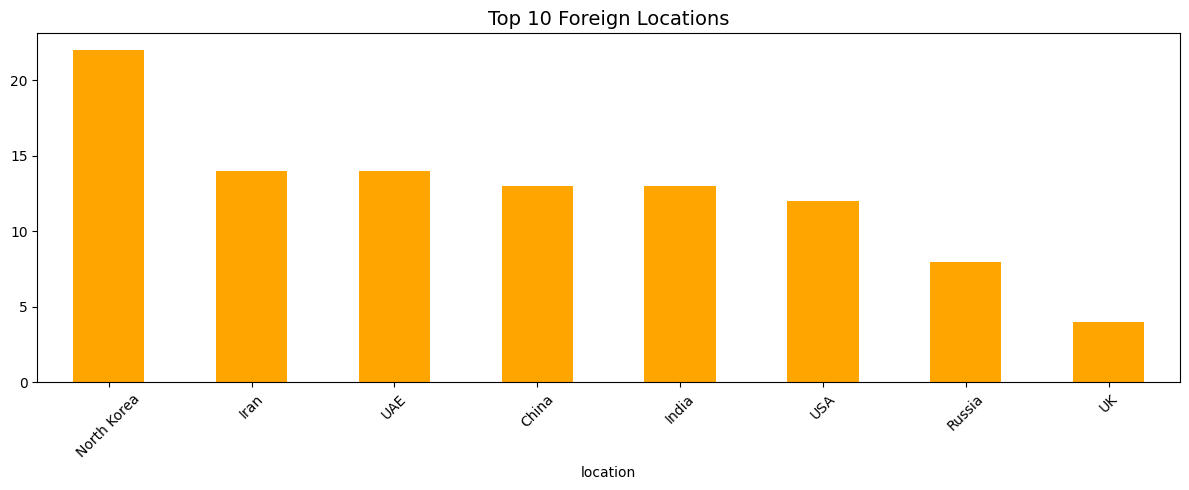

BadRequestError: BadRequestError(400, 'search_phase_execution_exception', 'No mapping found for [threat_score] in order to sort on')

In [6]:
# %% [markdown]
# # 🔍 Threat Hunting 101 - Cybersecurity Investigation

# %% [markdown]
# ## Setup
import pandas as pd
import numpy as np
from elasticsearch import Elasticsearch
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

es = Elasticsearch(['http://localhost:9200'])

# %% [markdown]
# ## 1. 🕐 Raat Ke Time Activity (Suspicious)

# %%
query = {
    "query": {
        "script": {
            "script": {
                "source": "doc['timestamp'].value.hour <= 5",
                "lang": "painless"
            }
        }
    },
    "size": 100
}

result = es.search(index='security-logs', body=query)
night_logs = [hit['_source'] for hit in result['hits']['hits']]
df_night = pd.DataFrame(night_logs)

print(f"🌙 Raat ko total activities: {len(df_night)}")
if len(df_night) > 0:
    print("\n👤 Users:")
    print(df_night['user_id'].value_counts())
    
    plt.figure(figsize=(10,5))
    df_night['user_id'].value_counts().plot(kind='bar', color='darkred', edgecolor='black')
    plt.title('Night Activity (12AM-5AM)', fontsize=14)
    plt.xlabel('User ID', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 2. 🌍 Foreign Location Access

# %%
query2 = {
    "query": {
        "bool": {
            "must_not": [
                {"term": {"location.keyword": "Pakistan"}}
            ]
        }
    },
    "size": 100
}

result2 = es.search(index='security-logs', body=query2)
foreign_logs = [hit['_source'] for hit in result2['hits']['hits']]
df_foreign = pd.DataFrame(foreign_logs)

print(f"✈️ Foreign locations: {len(df_foreign)}")
if len(df_foreign) > 0:
    print("\n🌍 Countries:")
    print(df_foreign['location'].value_counts().head(10))
    
    plt.figure(figsize=(12,5))
    df_foreign['location'].value_counts().head(10).plot(kind='bar', color='orange')
    plt.title('Top 10 Foreign Locations', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 3. 🚨 High Threat Score Users

# %%
query3 = {
    "query": {
        "range": {
            "threat_score": {"gte": 0.7}
        }
    },
    "size": 50,
    "sort": [{"threat_score": "desc"}]
}

result3 = es.search(index='security-logs', body=query3)
threat_logs = [hit['_source'] for hit in result3['hits']['hits']]
df_threats = pd.DataFrame(threat_logs)

print(f"🚨 High threat alerts: {len(df_threats)}")
if len(df_threats) > 0:
    print("\n👤 Threat Users:")
    print(df_threats[['user_id', 'threat_score', 'location', 'device']].head(10))

# %% [markdown]
# ## 4. 📊 Threat Score Distribution

# %%
query4 = {"query": {"match_all": {}}, "size": 1000}
result4 = es.search(index='security-logs', body=query4)
all_logs = [hit['_source'] for hit in result4['hits']['hits']]
df_all = pd.DataFrame(all_logs)

if 'threat_score' in df_all.columns:
    plt.figure(figsize=(10,5))
    df_all['threat_score'].hist(bins=30, color='steelblue', edgecolor='black')
    plt.axvline(x=0.7, color='red', linestyle='--', label='Alert Threshold (0.7)')
    plt.title('Threat Score Distribution', fontsize=14)
    plt.xlabel('Threat Score', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    plt.tight_layout()
    plt.show()

# %% [markdown]
# ## 5. 🔍 Suspicious User Deep Dive

# %%
suspicious_user = 'ali'  # Change karo jisko investigate karna hai

query5 = {
    "query": {
        "bool": {
            "must": [
                {"term": {"user_id.keyword": suspicious_user}},
                {"range": {"threat_score": {"gte": 0.5}}}
            ]
        }
    },
    "size": 20,
    "sort": [{"threat_score": "desc"}]
}

result5 = es.search(index='security-logs', body=query5)
user_logs = [hit['_source'] for hit in result5['hits']['hits']]
df_user = pd.DataFrame(user_logs)

print(f"👤 {suspicious_user} - Suspicious Activities:")
if len(df_user) > 0:
    print(df_user[['timestamp', 'location', 'device', 'files_accessed', 'threat_score']])

print("\n✅ Threat Hunting Complete!")